# Trabajo Práctico: Análisis de Precios de Viviendas

# 1. Índice

## 1. Índice

---

## 2. Configuración del Entorno y Carga de Datos

---

## 3. Análisis Exploratorio de Datos (EDA)
### 3.1. Inspección Preliminar y estadísticas descriptivas
### 3.2. Visualización de datos
### 3.3. Análisis de dipersión
### 3.4. Matriz de Correlación
### 3.5. Análisis de relaciones entre variables

---

## 4. Preprocesamiento de Datos
### 4.1. Manejo de datos faltantes
### 4.2. División Train/Test
### 4.3. Imputación y escalado

# 2. Configuración del Entorno y Carga de Datos

In [241]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

In [242]:
# Carga de datos
data_houses = pd.read_csv("house-prices-tp.csv")

In [243]:
# Cambio de la variable CHAS al tipo correcto
data_houses['CHAS'] = data_houses['CHAS'].astype('category')

In [244]:
data_houses.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,18.5,395.15,8.44,22.2
1,0.08265,0.0,13.92,0.0,0.437,6.127,18.4,5.5027,4.0,289.0,16.0,396.90,8.58,23.9
2,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9
3,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45,19.7
4,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67,26.5


# 3. Análisis Exploratorio de Datos (EDA)

## 3.1 Inspección preliminar

In [245]:
# Conteo y proporción de valores faltantes
missing_values = data_houses.isnull().sum()
missing_values = missing_values.to_frame().T

propor_faltantes = (data_houses.isna().sum()/data_houses.shape[0])*100
propor_faltantes = propor_faltantes.to_frame().T

# Estadística descriptiva
desc_stats = data_houses.describe()

# Correlación de cada variable (X) con MEDV (Y)
correlations = data_houses.corr()['MEDV'].sort_values(ascending=False)
correlations = correlations.to_frame().T


print("Informacion de variables")
print("="*60)
data_houses.info()

print("\n\nValores faltantes por categoria y porcentaje")
print("="*60)
display(missing_values)
display(propor_faltantes)

print("\n\nEstadisticas descriptivas")
print("="*60)
display(desc_stats)

print("\n\nCorrelaciones entre variables con MEDV")
print("="*60)
display(correlations)

Informacion de variables
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     533 non-null    float64 
 1   ZN       534 non-null    float64 
 2   INDUS    541 non-null    float64 
 3   CHAS     533 non-null    category
 4   NOX      532 non-null    float64 
 5   RM       535 non-null    float64 
 6   AGE      532 non-null    float64 
 7   DIS      541 non-null    float64 
 8   RAD      528 non-null    float64 
 9   TAX      538 non-null    float64 
 10  PTRATIO  528 non-null    float64 
 11  B        534 non-null    float64 
 12  LSTAT    534 non-null    float64 
 13  MEDV     535 non-null    float64 
dtypes: category(1), float64(13)
memory usage: 57.3 KB


Valores faltantes por categoria y porcentaje


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,23,22,15,23,24,21,24,15,28,18,28,22,22,21


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,4.136691,3.956835,2.697842,4.136691,4.316547,3.776978,4.316547,2.697842,5.035971,3.23741,5.035971,3.956835,3.956835,3.776978




Estadisticas descriptivas


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,533.000000,534.000000,541.000000,532.000000,535.000000,532.000000,541.000000,528.000000,538.000000,528.000000,534.000000,534.000000,535.000000
mean,5.845517,13.197175,11.218725,0.560050,6.291839,67.632303,3.944102,9.699379,409.575089,18.429904,347.806040,13.028092,22.746809
std,13.828631,24.902981,6.942021,0.119472,0.782403,28.461925,2.255689,8.684495,167.689379,2.194759,99.636208,7.579972,9.491452
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.084470,0.000000,5.130000,0.453000,5.875500,42.275000,2.112100,4.000000,279.000000,17.000000,369.530000,7.150000,16.750000
50%,0.315330,0.000000,9.690000,0.538000,6.208000,76.500000,3.340107,5.000000,335.000000,19.000000,390.815000,11.465000,21.200000
75%,4.871410,20.000000,18.100000,0.643986,6.638500,93.825000,5.400700,23.632660,666.000000,20.200000,395.890000,17.205000,26.300000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000




Correlaciones entre variables con MEDV


,MEDV,RM,ZN,B,DIS,CHAS,CRIM,RAD,NOX,AGE,INDUS,TAX,PTRATIO,LSTAT
MEDV,1.0,0.58808,0.361685,0.27,0.223008,0.206189,-0.22833,-0.342224,-0.360711,-0.39659,-0.418512,-0.4377,-0.47515,-0.652613


In [246]:
# Separacion de variables por tipo
cols_numericas = data_houses.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = data_houses.select_dtypes(include=['category', 'object']).columns.tolist()

print(f'Variables numericas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variables categoricas ({len(cols_categoricas)}): {cols_categoricas}')

Variables numericas (13): ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
Variables categoricas (1): ['CHAS']


El dataset contiene informacion de precios de casas de Boston con las siguientes variables:

| Variable | Tipo | Descripcion |
|----------|------|-------------|
| `CRIM` | Continua | tasa de criminalidad per cápita por ciudad  |
| `ZN` | Continua | proporción de terrenos residenciales zonificados para lotes de más de 25,000 pies cuadrados |
| `INDUS` | Continua | proporción de acres de negocios no minoristas por ciudad |
| `CHAS` | Cualitativa | variable dummy del río Charles (1 si el tramo limita con el río; 0 de lo contrario) |
| `NOX` | Continua | concentración de óxidos de nitrógeno (partes por 10 millones) [parts/10M]
| `RM` | Continua | número promedio de habitaciones por vivienda |
| `AGE` | Continua | proporción de unidades ocupadas por sus propietarios construidas antes de 1940|
| `DIS` | Continua | distancias ponderadas a cinco centros de empleo de Boston|
| `RAD` | Continua | índice de accesibilidad a las autopistas radiales |
| `TAX` | Continua | tasa de impuesto sobre la propiedad a valor completo por $10,000 [$/10k] (Ejemplo: si TAX = 500, entonces el impuesto promedio es 5%) |
| `PTRATIO` | Continua | proporción alumno-maestro por ciudad |
| `B` | Continua | El resultado de la ecuación $$B = 1000(B_k - 0.63)^2$$ donde $$B_k$$ es la proporciòn de negros por ciudad |
| `LSTAT` | Continua | % de población de menor estatus socioeconómico |
| `MEDV` | Continua | Valor mediano de las viviendas ocupadas por sus propietarios en miles de dólares [k$] |



Cada observación se corresponde con un distrito, pueblo o zona censal (census tract) del área metropolitana de Boston (no una vivienda individual), por lo que muchas de las variables provienen de agregaciones de viviendas individuales para dicha unidad.

## 3.2. Visualización de datos

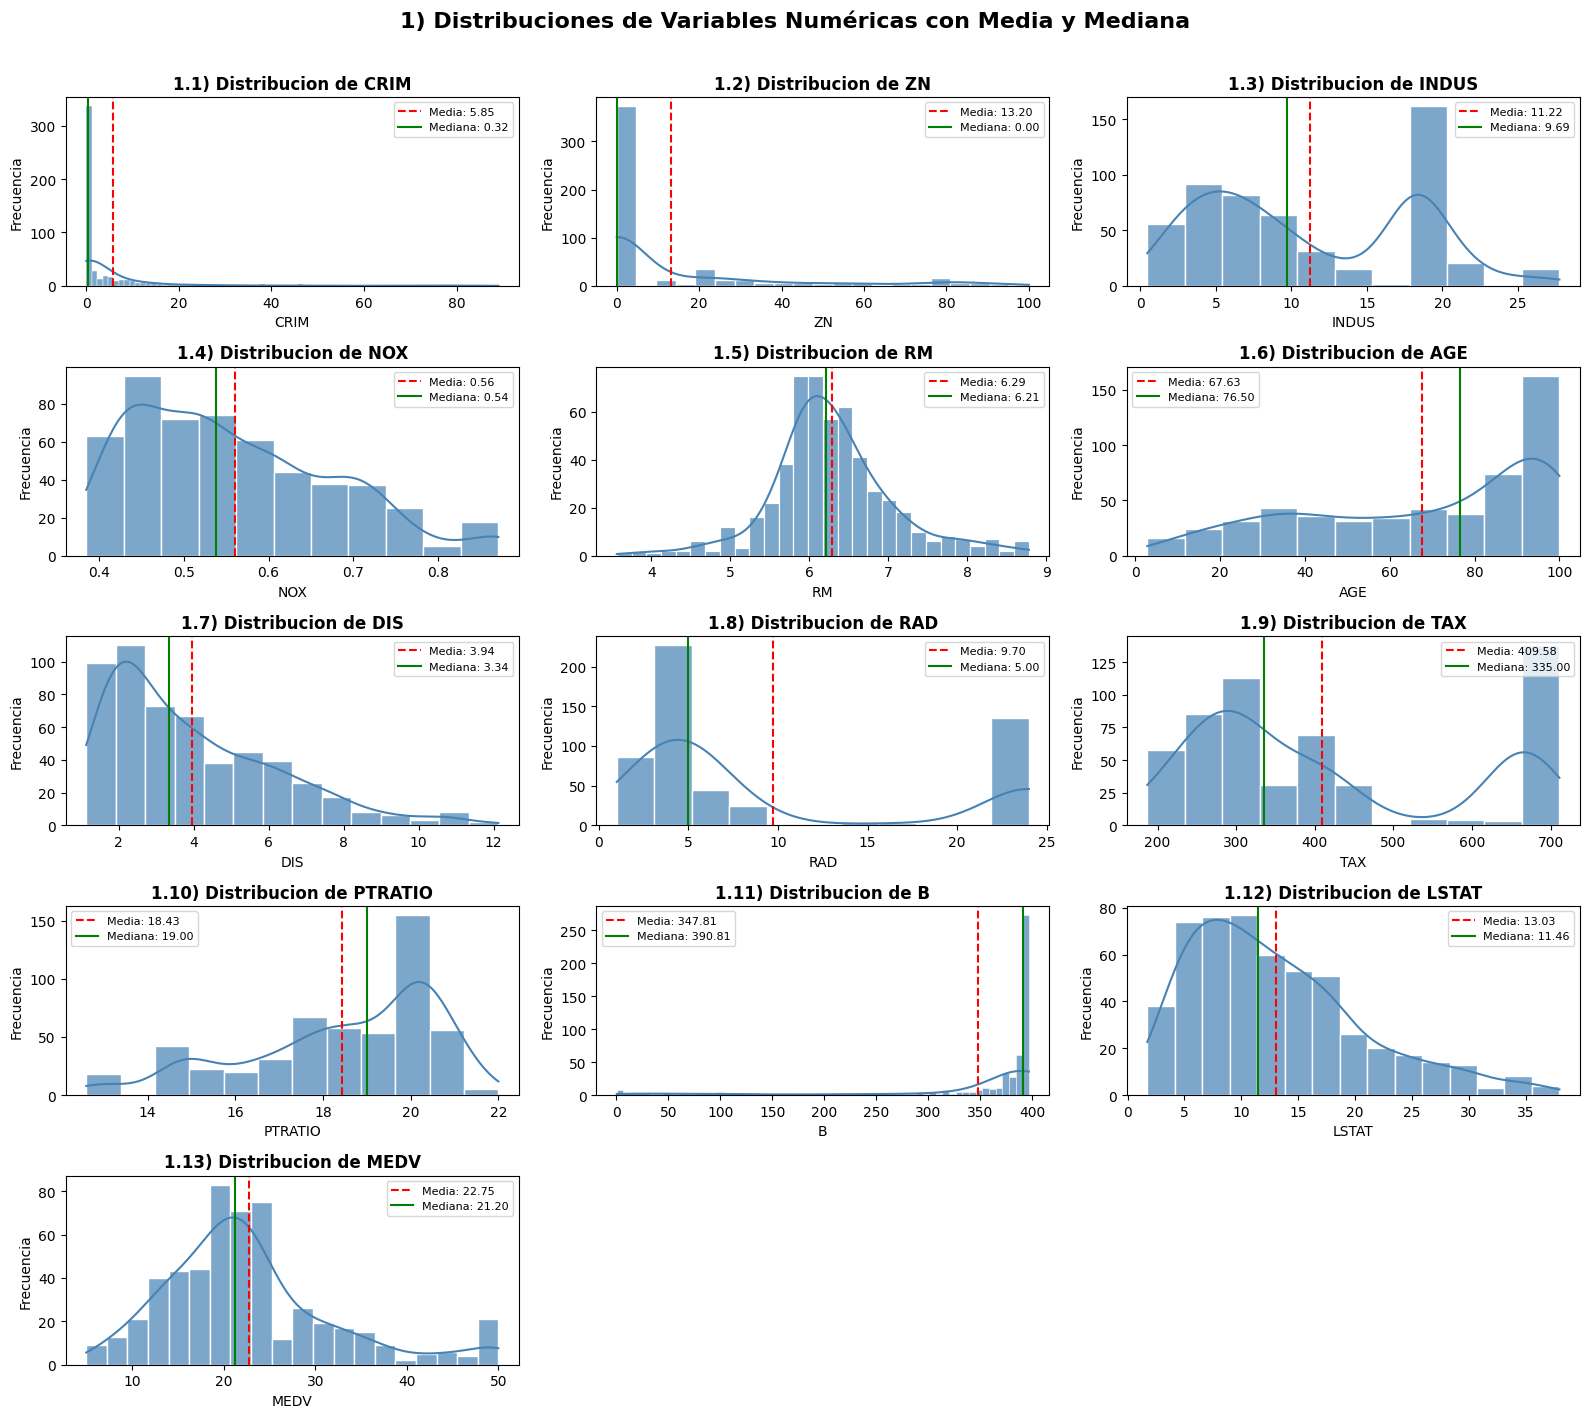

In [247]:
# Gráfico 1

# Configuración de la figura
fig, axes = plt.subplots(5, 3, figsize=(16
, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    sns.histplot(data_houses[col], kde=True, ax=ax, color='steelblue',
                 edgecolor='white', alpha=0.7)

    # Lineas de referencia: media y mediana
    media = data_houses[col].mean()
    mediana = data_houses[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5,
               label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=1.5,
               label=f'Mediana: {mediana:.2f}')

    ax.set_title(f'1.{i+1}) Distribucion de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# Desactiva ejes sobrantes si los hay
for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('1) Distribuciones de Variables Numéricas con Media y Mediana',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

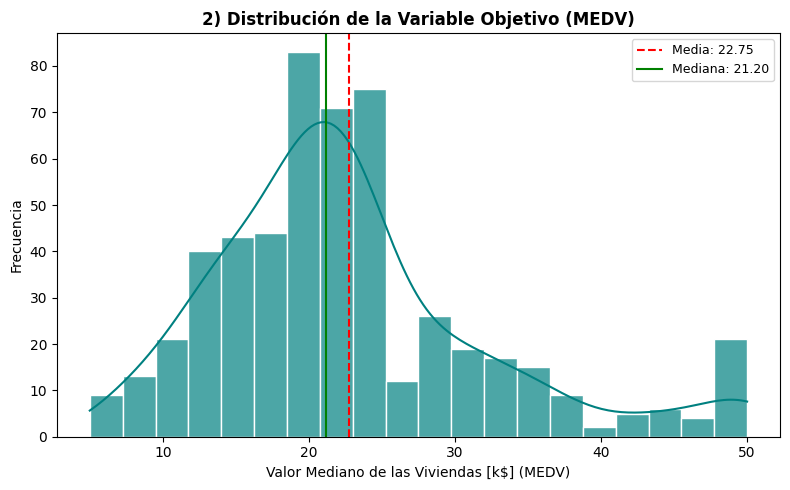

In [248]:
# Gráfico 2

# Configuración de la figura
fig, ax = plt.subplots(figsize=(8, 5))

# Visualización del Histograma + KDE para la variable objetivo (MEDV)
sns.histplot(
    data_houses['MEDV'],
    kde=True,
    ax=ax,
    color='teal',
    edgecolor='white',
    alpha=0.7,
)

# Cálculo y líneas de referencia para la Media y la Mediana
media_medv = data_houses['MEDV'].mean()
mediana_medv = data_houses['MEDV'].median()

ax.axvline(
    media_medv,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Media: {media_medv:.2f}',
)
ax.axvline(
    mediana_medv,
    color='green',
    linestyle='-',
    linewidth=1.5,
    label=f'Mediana: {mediana_medv:.2f}',
)

# Títulos y etiquetas
ax.set_title(
    '2) Distribución de la Variable Objetivo (MEDV)',
    fontweight='bold',
    fontsize=12,
)
ax.set_xlabel('Valor Mediano de las Viviendas [k$] (MEDV)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

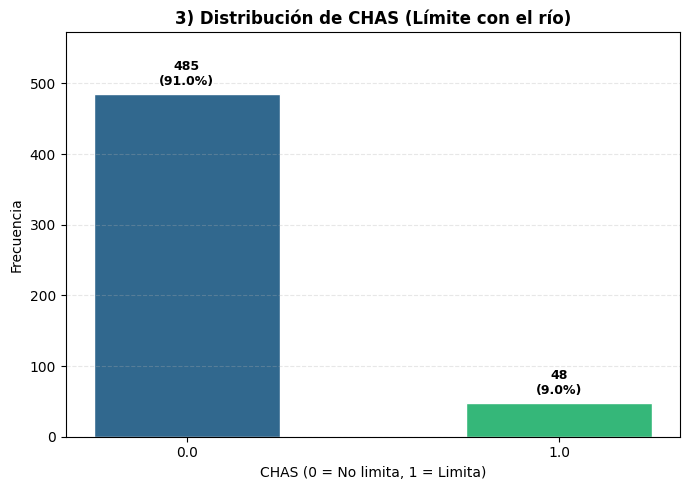

In [249]:
# Gráfico 3

# Configuración de la figura
fig, ax = plt.subplots(figsize=(7, 5))

conteo = data_houses['CHAS'].value_counts()
bars = ax.bar(
    conteo.index.astype(str),
    conteo.values,
    color=sns.color_palette('viridis', len(conteo)),
    edgecolor='white',
    width=0.5,  # Ancho de barra equilibrado
)

# Etiquetas con frecuencia y porcentaje
total = conteo.sum()
for bar, val in zip(bars, conteo.values):
  pct = val / total * 100
  ax.text(
      bar.get_x() + bar.get_width() / 2,
      bar.get_height() + (total * 0.015),
      f'{val}\n({pct:.1f}%)',
      ha='center',
      va='bottom',
      fontsize=9,
      fontweight='bold',
  )

ax.set_title('3) Distribución de CHAS (Límite con el río)', fontweight='bold')
ax.set_xlabel('CHAS (0 = No limita, 1 = Limita)')
ax.set_ylabel('Frecuencia')

# Eje X horizontal
ax.tick_params(axis='x', rotation=0)

# Margen superior para las etiquetas flotantes
ax.set_ylim(0, conteo.max() * 1.18)
ax.grid(True, linestyle='--', alpha=0.3, axis='y')  # Grilla suave en Y

plt.tight_layout()
plt.show()

## 3.3. Análisis de dispersión

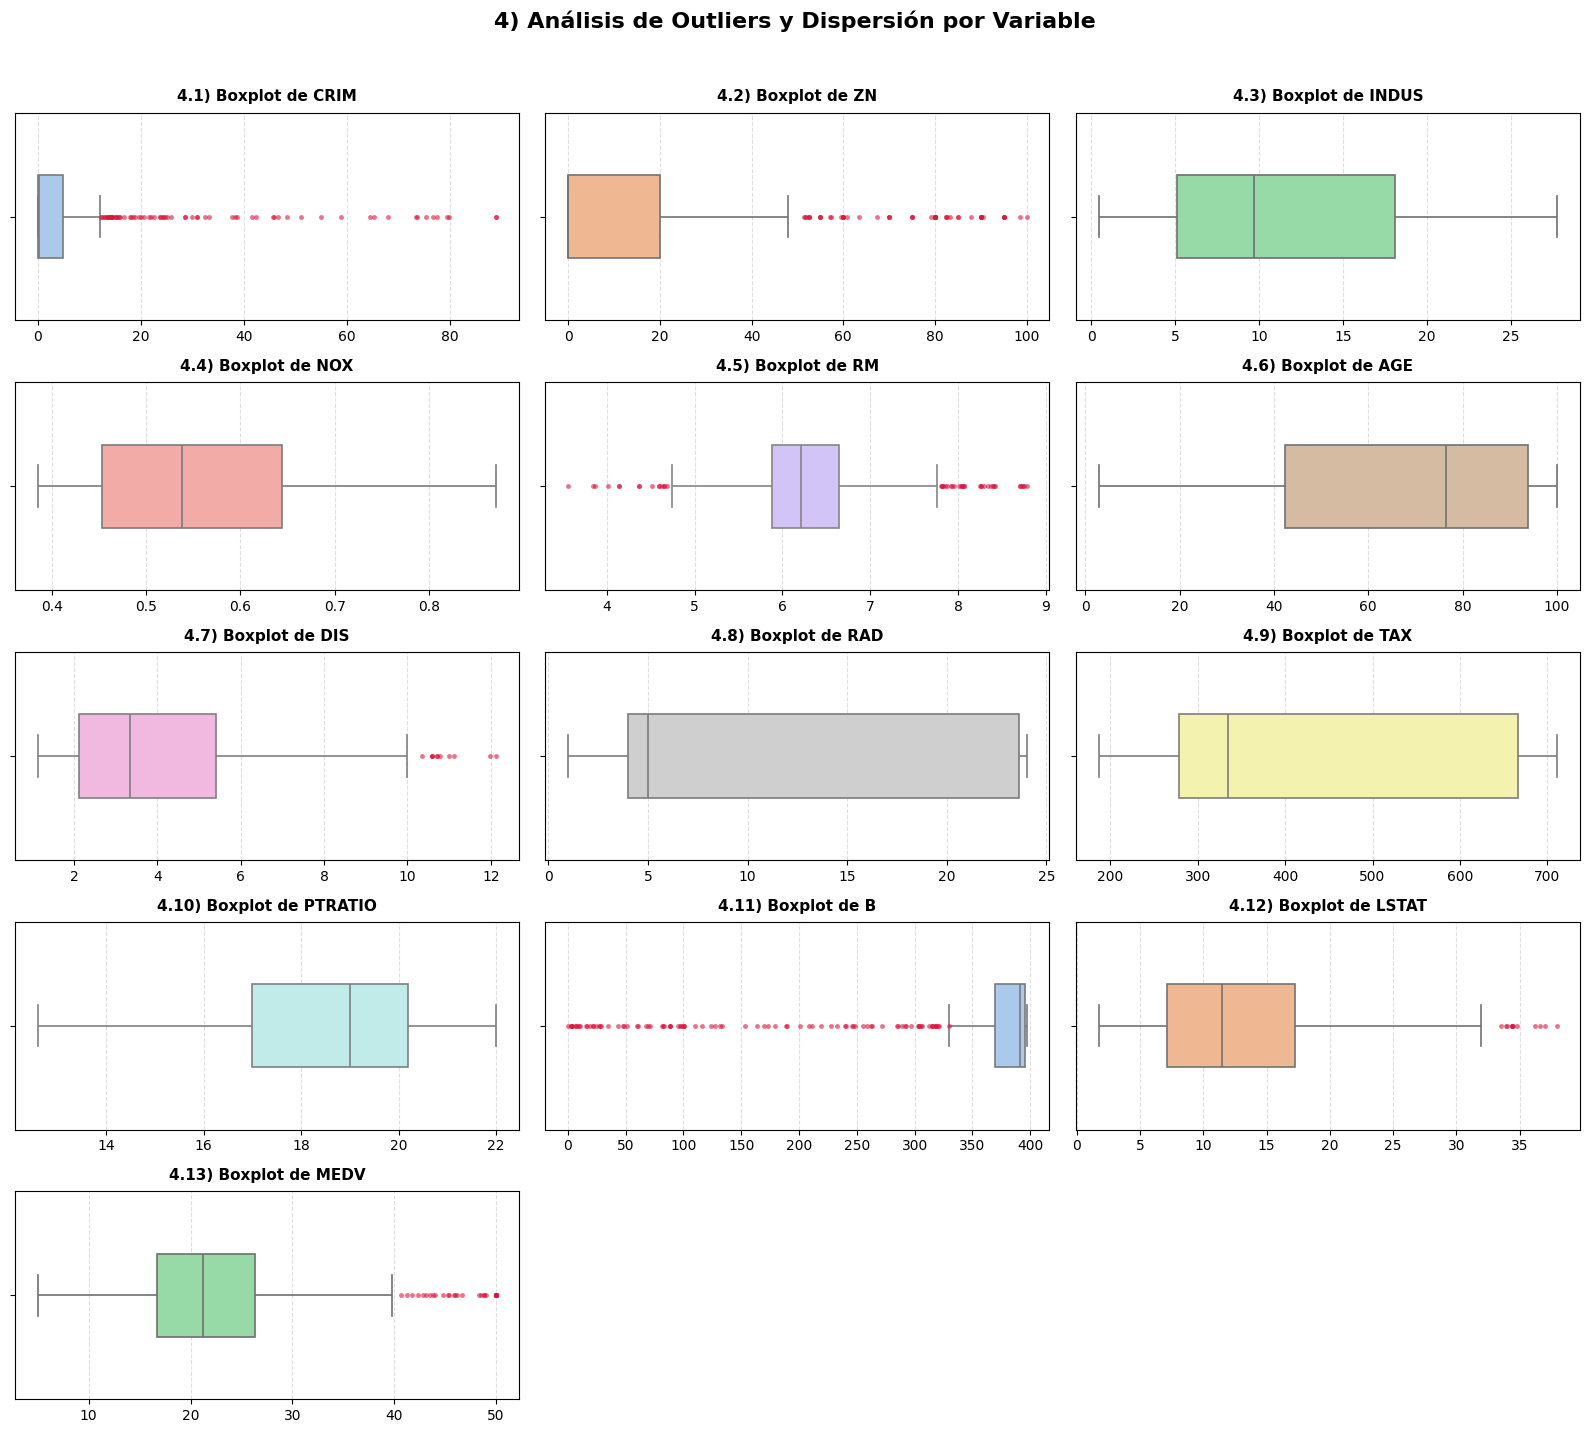

In [250]:
# Gráfico 4

# Configuración de la figura
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(16, 14))
axes = axes.flatten()

# Paleta de colores personalizada
palette = sns.color_palette('pastel', len(cols_numericas))

for i, col in enumerate(cols_numericas):
    ax = axes[i]

    # Boxplot estilizado
    sns.boxplot(
        data=data_houses,
        x=col,
        ax=ax,
        color=palette[i],
        fliersize=3.5,  # Tamaño de los outliers
        flierprops=dict(
            marker='o', markerfacecolor='crimson', alpha=0.6, markeredgecolor='none'
        ),  # Outliers destacados en rojo
        linewidth=1.2,
        width=0.4,
    )

    # Personalización del subplot
    ax.set_title(f'4.{i+1}) Boxplot de {col}', fontweight='bold', fontsize=11, pad=8)
    ax.set_xlabel('')
    ax.grid(True, linestyle='--', alpha=0.4, axis='x')  # Grilla suave horizontal

# Desactiva ejes sobrantes
for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    '4) Análisis de Outliers y Dispersión por Variable',
    fontsize=16,
    fontweight='bold',
    y=1.02,
)
plt.tight_layout()
plt.show()

## 3.4. Matriz de correlación

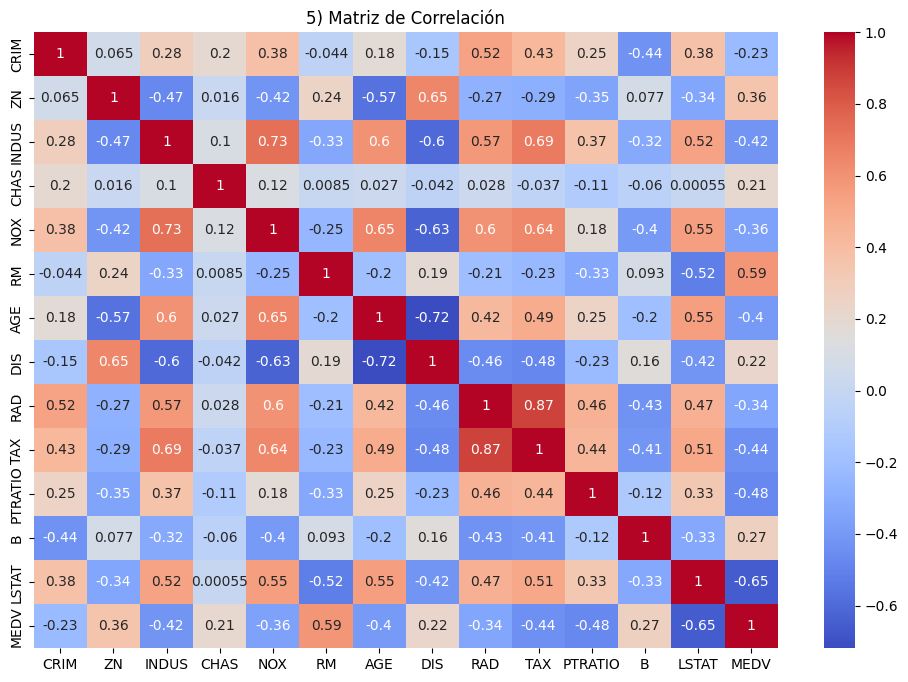

In [251]:
# Gráfico 5

# Configuración de la figura
plt.figure(figsize=(12,8))
correlation_matrix = data_houses.corr()
sns.heatmap(correlation_matrix, annot = True,cmap='coolwarm')
plt.title('5) Matriz de Correlación')
plt.show()

## 3.5. Análisis de relaciones entre variables

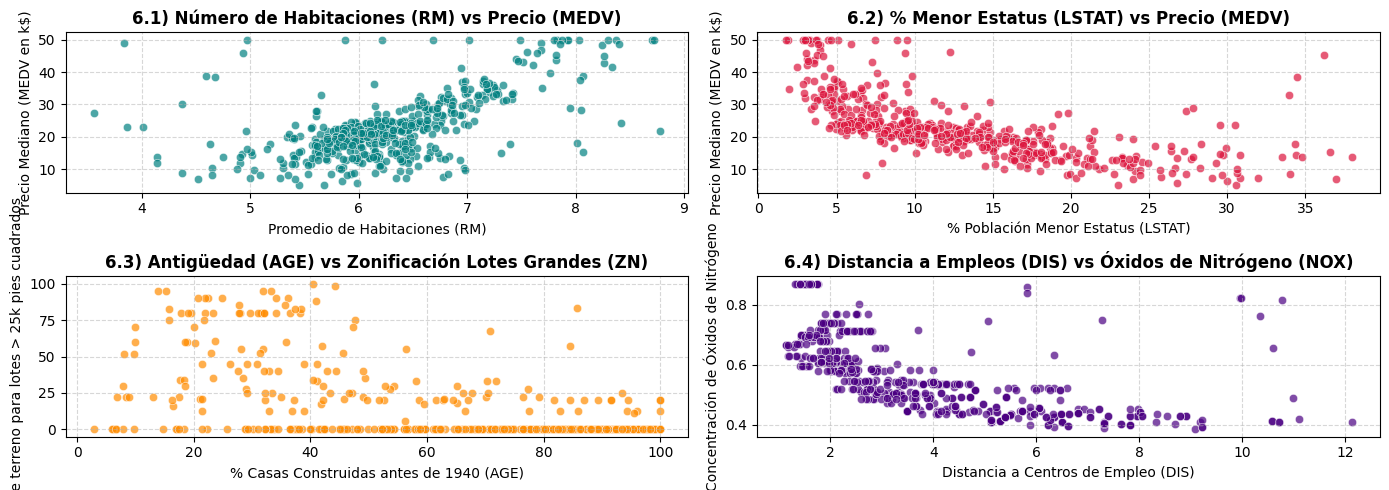

In [252]:
# Gráfico 6

# Configuración de la figura
plt.figure(figsize=(14, 5))

# Scatterplot 1: RM vs MEDV (Relación positiva)
plt.subplot(2, 2, 1)
sns.scatterplot(data=data_houses, x='RM', y='MEDV', alpha=0.7, color='teal')
plt.title('6.1) Número de Habitaciones (RM) vs Precio (MEDV)', fontweight='bold')
plt.xlabel('Promedio de Habitaciones (RM)')
plt.ylabel('Precio Mediano (MEDV en k$)')
plt.grid(True, linestyle='--', alpha=0.5)

# Scatterplot 2: LSTAT vs MEDV (Relación negativa)
plt.subplot(2, 2, 2)
sns.scatterplot(data=data_houses, x='LSTAT', y='MEDV', alpha=0.7, color='crimson')
plt.title('6.2) % Menor Estatus (LSTAT) vs Precio (MEDV)', fontweight='bold')
plt.xlabel('% Población Menor Estatus (LSTAT)')
plt.ylabel('Precio Mediano (MEDV en k$)')
plt.grid(True, linestyle='--', alpha=0.5)

# Scatterplot 3: AGE vs ZN
plt.subplot(2, 2, 3)
sns.scatterplot(data=data_houses, x='AGE', y='ZN', alpha=0.7, color='darkorange')
plt.title('6.3) Antigüedad (AGE) vs Zonificación Lotes Grandes (ZN)', fontweight='bold')
plt.xlabel('% Casas Construidas antes de 1940 (AGE)')
plt.ylabel('% de terreno para lotes > 25k pies cuadrados')
plt.grid(True, linestyle='--', alpha=0.5)

# Scatterplot 4: DIS vs NOX
plt.subplot(2, 2, 4)
sns.scatterplot(data=data_houses, x='DIS', y='NOX', alpha=0.7, color='indigo')
plt.title('6.4) Distancia a Empleos (DIS) vs Óxidos de Nitrógeno (NOX)', fontweight='bold')
plt.xlabel('Distancia a Centros de Empleo (DIS)')
plt.ylabel('Concentración de Óxidos de Nitrógeno')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 4. Preprocesamiento de datos

## 4.1. Datos faltantes


In [253]:
# 1. Tamaño original
filas_iniciales = data_houses.shape[0]
print(f"Tamaño original: {data_houses.shape}")
print('=' * 60)

# 2. Eliminación de registros donde TODAS las columnas sean NaN
data_houses = data_houses.dropna(how='all')
filas_post_full_nan = data_houses.shape[0]
eliminados_full_nan = filas_iniciales - filas_post_full_nan
print(f"Registros eliminados completamente de NaN = -{eliminados_full_nan}")
print(f"Tamaño actual: {data_houses.shape}")
print('=' * 60)

# 3. Eliminación de registros donde la variable objetivo (MEDV) sea nula
data_houses = data_houses.dropna(subset=['MEDV'])
filas_post_target = data_houses.shape[0]
eliminados_target = filas_post_full_nan - filas_post_target
print(f"Registros eliminados sin target (MEDV) = -{eliminados_target}")
print(f"Tamaño actual: {data_houses.shape}")
print('=' * 60)

# 4. Eliminación registros donde más del 50% de las features sean NaN
umbral_nan = len(data_houses.columns) * 0.5
data_houses_limpio = data_houses.dropna(thresh=int(len(data_houses.columns) - umbral_nan))
filas_post_umbral = data_houses_limpio.shape[0]
eliminados_umbral = filas_post_target - filas_post_umbral
print(f"Registros eliminados por umbral de NaNs (>50%) = -{eliminados_umbral}")
print(f"Tamaño final: {data_houses_limpio.shape}")
print('=' * 60)

data_houses = data_houses_limpio

Tamaño original: (556, 14)
Registros eliminados completamente de NaN = -1
Tamaño actual: (555, 14)
Registros eliminados sin target (MEDV) = -20
Tamaño actual: (535, 14)
Registros eliminados por umbral de NaNs (>50%) = -3
Tamaño final: (532, 14)


In [254]:
#Numero de datos faltantes por categoria
propor_faltantes = (data_houses.isna().sum()/data_houses.shape[0])*100
propor_faltantes = propor_faltantes.to_frame().T

propor_faltantes

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,1.503759,1.879699,0.18797,1.315789,1.315789,0.93985,1.691729,0.56391,2.067669,1.503759,1.315789,1.315789,1.315789,0.0


Se descartaron las filas con ausencia total de datos y aquellas donde la variable objetivo MEDV resultaba nula.

Se eliminaron los registros que contenían más del 50% de sus características faltantes. Intentar imputarlos puede generar ruido o sesgo.

Se logró bajar el porcentaje de datos faltantes en cada variable.

## 4.2. Division TRAIN-TEST


In [255]:
# Separar features (X) del target (y)
X = data_houses.drop('MEDV', axis=1)
y = data_houses['MEDV']

# División Train-Test (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de Train: {X_train.shape}")
print(f"Dimensiones de Test:  {X_test.shape}")

Dimensiones de Train: (425, 13)
Dimensiones de Test:  (107, 13)


Esta división debe realizarse antes de imputar datos faltantes y antes de escalar las variables. Las medidas resumen empleadas en el escalado de datos deben estar limpias de intervencion previa (prevenir Data Leakage).

Se determinó una división de 80% Train y 20% test.

## 4.3. Imputacion y escalado

In [256]:
# Separacion de variables categoricas
num_cols = cols_numericas[:12] #
cat_cols = cols_categoricas #


# Imputacion de variables numéricas
imputer_num = SimpleImputer(strategy='median') #
X_train_num_imputed = imputer_num.fit_transform(X_train[num_cols]) #
X_test_num_imputed = imputer_num.transform(X_test[num_cols]) #

imputer_cat = SimpleImputer(strategy='most_frequent') #
X_train_cat_imputed = imputer_cat.fit_transform(X_train[cat_cols]) #
X_test_cat_imputed = imputer_cat.transform(X_test[cat_cols]) #

# Escalado
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num_imputed)
X_test_num_scaled = scaler.transform(X_test_num_imputed)


X_train_scaled = pd.DataFrame(X_train_num_scaled, columns=num_cols, index=X_train.index)
X_train_scaled['CHAS'] = X_train_cat_imputed

X_test_scaled = pd.DataFrame(X_test_num_scaled, columns=num_cols, index=X_test.index)
X_test_scaled['CHAS'] = X_test_cat_imputed


Para el tratamiento de datos faltantes en las variables explicativas ($X$), se utilizó `SimpleImputer` con la estrategia de la mediana. Esta elección se basa en que la mediana es una medida de tendencia central robusta frente a la asimetría y a la presencia de outliers.

En la variable `'CHAS'` se utilizó la moda.